# **Libraries**

In [1]:
import os
import zipfile
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import json
import pickle
from pydub import AudioSegment
import librosa
import soundfile as sf
from IPython.display import Audio
import scipy.signal as signal
from scipy.signal import firwin, lfilter
from librosa.effects import trim
import tensorflow as tf
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D,SeparableConv2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score ,roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, auc,classification_report



In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Exploration**

In [ ]:
zip_path = "/content/drive/MyDrive/data3/data3.zip"
extract_to = "/content/drive/MyDrive/data3/data3"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Extracted")
print(os.listdir(extract_to))


In [3]:
TARGET_SR = 16000
SILENCE_THRESHOLD_DB = -40.0 #Any RMS frame below -40 dB is considered silent for computing silence_fraction

#computes audio statistics
def compute_stats(filepaths):
    durations = []
    rms_list = []
    peak_list = []
    silence_fraction = []

    for p in filepaths:
        try:
            y, sr = librosa.load(p, sr=TARGET_SR, mono=True)
        except Exception as e:
            print("ERROR loading", p, e)
            continue

        durations.append(len(y) / TARGET_SR)

        rms = np.sqrt(np.mean(y**2)) if y.size>0 else 0.0   #Measures average loudness of the audio
        rms_list.append(rms)       #Finds peak amplitude (absolute max value), represents loudest point in the audio

        peak = np.max(np.abs(y)) if y.size>0 else 0.0
        peak_list.append(peak)

        S = librosa.feature.rms(y=y)[0]
        S_db = 20 * np.log10(np.maximum(S, 1e-12))
        silence_fraction.append(np.sum(S_db < SILENCE_THRESHOLD_DB) / len(S_db))

    #Converts RMS and peak lists to decibels for reporting statistics
    rms_db = 20 * np.log10(np.maximum(rms_list, 1e-12))
    peak_db = 20 * np.log10(np.maximum(peak_list, 1e-12))

    return {
        "count": len(durations), #total number of files
        "duration_mean": float(np.mean(durations)), #average and standard deviation of audio lengths
        "duration_std": float(np.std(durations)),
        "rms_db_mean": float(np.mean(rms_db)), #loudness mean/std in dB
        "rms_db_std": float(np.std(rms_db)),
        "peak_db_mean": float(np.mean(peak_db)), #peak loudness mean/std in dB
        "peak_db_std": float(np.std(peak_db)),
        "silence_frac_mean": float(np.mean(silence_fraction)), #average fraction of silence
    }

def audit_dataset(dataset_root):
    report = {}
    for cls in ["cry", "not_cry"]:
        folder = os.path.join(dataset_root, cls)
        if not os.path.isdir(folder):
            report[cls] = {"error": "folder missing"}
            continue

        files = glob(folder + "/**/*.*", recursive=True)
        files = [f for f in files if f.lower().endswith((".wav", ".mp3", ".flac", ".m4a", ".ogg"))]

        print(f"Found {len(files)} {cls} files")
        report[cls] = compute_stats(files)

    return report

In [4]:
report = audit_dataset("/content/drive/MyDrive/data3/data3")
report


Found 1036 cry files
Found 922 not_cry files


{'cry': {'count': 1036,
  'duration_mean': 6.688919522200772,
  'duration_std': 0.6318925608678971,
  'rms_db_mean': -23.056814193725586,
  'rms_db_std': 8.7627534866333,
  'peak_db_mean': -5.042019844055176,
  'peak_db_std': 6.6237592697143555,
  'silence_frac_mean': 0.33015410284632024},
 'not_cry': {'count': 922,
  'duration_mean': 5.43512052603037,
  'duration_std': 0.6637500566850737,
  'rms_db_mean': -36.40046691894531,
  'rms_db_std': 14.573575973510742,
  'peak_db_mean': -17.903982162475586,
  'peak_db_std': 16.009634017944336,
  'silence_frac_mean': 0.6130445371884038}}

# **Preprocessing and Feature extraction**

**load_and_normalize(file_path, target_sr=16000)**
* Check file type: Looks at the file extension (like .wav or .mp3).
 * If file is not WAV: it loads the file and writes a new .wav copy with the sample rate target_sr (16000 Hz). This ensures all files are WAV and have the same sampling frequency.

* Normalize volume: divides the audio by its maximum absolute value so the loudest sample becomes 1.0 and the quietest -1.0. This makes volume consistent across files.

* Return: (y, sr, file_path): the audio samples, sample rate, and possibly the new WAV path.

* Different audio files may be recorded with different devices or saved using different formats. Converting to a single format and sample rate is like making sure every picture in a photo album is the same size — easier to compare.

* Normalizing volume is like setting everyone's microphone to the same volume so the model isn’t tricked by loudness differences.

In [5]:
# ============================================
# 1. CONVERT → LOAD → NORMALIZE
# ============================================
def load_and_normalize(file_path, target_sr=16000):
    base, ext = os.path.splitext(file_path)
    # Convert non-WAV to WAV
    if ext.lower() != ".wav":
        y_temp, _ = librosa.load(file_path, sr=target_sr, mono=True)
        new_path = base + ".wav"
        sf.write(new_path, y_temp, target_sr)
        file_path = new_path
    # Load WAV
    y, sr = librosa.load(file_path, sr=target_sr, mono=True)
    # Normalize
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))
    return y, sr, file_path


**mild_trim(y, top_db=40)**
* Removes long silent parts at the start and end of the audio, but keeps quiet pauses inside the sound.

* Think of cutting away the blank space at the start and end of a recorded sentence but leaving the short pauses between words intact.
* Leading/trailing silence is irrelevant for classification and wastes time + space. But removing inner pauses would remove important natural pauses in a baby cry, so the function intentionally keeps them.

* Parameter top_db:
  * Controls how “quiet” a segment needs to be to count as silence. Larger value → only very loud portions considered signal; smaller value → quieter parts considered signal.

In [6]:
# ============================================
# 2. TRIM ONLY LONG SILENCES (keep inner pauses)
# ============================================
def mild_trim(y, top_db=40):
    y_trimmed, _ = trim(y, top_db=top_db)
    return y_trimmed


**fix_length(y, sr=16000, target_seconds=6)**
* Makes every audio file exactly the same duration (by default, 6 seconds).
* Compute target_len = target_seconds * sr (6 * 16000 = 96,000 samples).
* If audio is longer, cut it to the first target_len samples.
* If audio is shorter, pad it at the end with zeros (silence) until it reaches target_len.
* Machine learning models require inputs of the same shape. This function ensures uniform length so later steps produce the same-sized outputs.


In [7]:

# ============================================
# 3. FIX LENGTH TO EXACT TARGET DURATION
# ============================================
def fix_length(y, sr=16000, target_seconds=6):
    target_len = int(target_seconds * sr)

    if len(y) > target_len:
        return y[:target_len]

    return np.pad(y, (0, target_len - len(y)))



**augment_audio(y, sr=16000)**
* Produces several modified versions of a given audio clip to simulate variability and increase the size of the training set. It returns a dictionary with different augmented versions.

* Time shift ("shift"): prepend a short silence at the beginning and drop the same amount at the end — the sound starts slightly later.

* Time stretch ("stretch"): speed up the audio slightly (1.1x) — pitch may be preserved or slightly altered by the library. Then it’s fixed back to the same length.

* Pitch shift ("pitch"): shift the pitch up by 2 semitones (makes sound higher). Then fix length.

* Add noise ("noise"): add a tiny random noise signal and renormalize to keep volume consistent.

* It exposes the model to small variations — like the same cry recorded with a different phone, or heard from a slightly different distance — so the model learns the core pattern rather than memorizing exact samples.

* Time stretching and pitch shifting can create tiny artifacts (unnatural clicks) sometimes — this usually helps robustness.

* The shift is one-direction only (always delays the start).

In [8]:
# ============================================
# 4. DATA AUGMENTATION
# ============================================
def augment_audio(y, sr=16000):
    augmented = {}

    # --- Time shift ---
    shift = int(0.1 * sr)
    augmented["shift"] = np.concatenate([np.zeros(shift), y[:-shift]])

    # --- Stretch ---
    try:
        stretched = librosa.effects.time_stretch(y, 1.1)
        augmented["stretch"] = fix_length(stretched, sr)
    except:
        augmented["stretch"] = y

    # --- Pitch shift ---
    try:
        pitched = librosa.effects.pitch_shift(y, sr, n_steps=2)
        augmented["pitch"] = fix_length(pitched, sr)
    except:
        augmented["pitch"] = y

    # --- Add noise ---
    noisy = y + 0.005 * np.random.randn(len(y))
    if np.max(np.abs(noisy)) > 0:
        noisy = noisy / np.max(np.abs(noisy))
    augmented["noise"] = noisy

    return augmented


**preprocess_file(file_path, sr=16000, target_seconds=6, top_db=40, augment=False)**

* Runs the full preprocessing pipeline for one file and returns processed audio versions.
  * load_and_normalize: convert to WAV and normalize volume.
  
  * mild_trim: remove long silence at start/end.
  * fix_length: make the audio exactly 6 seconds.
  * Build results = {"original": y}: store the original processed audio.
  * If augment=True, call augment_audio and add the augmented variants into results.
  * Return results, which is a dictionary where keys are names like "original", "shift", "stretch", etc., and values are the audio arrays.

* One function to process a file end-to-end and optionally produce its augmented children.

In [9]:
# ============================================
# 5. FULL PREPROCESS FUNCTION
# ============================================
def preprocess_file(file_path, sr=16000, target_seconds=6, top_db=40, augment=False):
    y, sr, file_path = load_and_normalize(file_path, target_sr=sr)
    y = mild_trim(y, top_db=top_db)
    y = fix_length(y, sr=sr, target_seconds=target_seconds)

    results = {"original": y}
    if augment:
        results.update(augment_audio(y, sr))

    return results


* DATA_PATH: path where raw cry and not_cry folders are located.

* cry_files / nc_files — lists of file paths for each class.

* labels: list of 1s for cry, 0s for not_cry (the target the model should learn).

* train_test_split(...) — splits all_files and labels into training and testing sets with test_size=0.2 (20% test data), preserving class proportions (stratify=labels) and reproducible (random_state=42).

* Split BEFORE processing to avoid data leakage. Files used in training (and their augmentations) must not appear in test set. Splitting first ensures that augmented versions are only created for training files.

* Folder creation:
  * OUT is the Processed folder that will hold train and test subfolders. The code ensures these folders exist.

* Training loop: saving processed files
  * For each training file (and its label):
    * Determine class folder: train/cry or train/not_cry.
    * Process the file with preprocess_file(..., augment=True) so you get original + augmented versions.
    * Save each variant as a WAV file named like originalfilename_shift.wav, originalfilename_pitch.wav, etc.

* Test loop: saving test files (NO augmentation)
  * For each test file:
   * Process with preprocess_file(..., augment=False) so you only get the single standardized file (original).
   * Save into test/cry or test/not_cry.
   * Test set must reflect real-world (unseen) data, not artificially expanded or altered versions of training examples. This keeps evaluation fair and honest.  

In [10]:
# ============================================
# 6. BUILD CLEAN TRAIN & TEST DATASET
# ============================================
DATA_PATH = "/content/drive/MyDrive/data3/data3"

cry_files = [os.path.join(DATA_PATH, "cry", f) for f in os.listdir(f"{DATA_PATH}/cry")]
nc_files = [os.path.join(DATA_PATH, "not_cry", f) for f in os.listdir(f"{DATA_PATH}/not_cry")]

all_files = cry_files + nc_files
labels = [1] * len(cry_files) + [0] * len(nc_files)

train_files, test_files, y_train_labels, y_test_labels = train_test_split(
    all_files, labels, test_size=0.2, random_state=42, stratify=labels
)

print("Train:", len(train_files))
print("Test:", len(test_files))

OUT = "/content/drive/MyDrive/data3/Processed"
TRAIN_OUT = f"{OUT}/train"
TEST_OUT = f"{OUT}/test"

os.makedirs(TRAIN_OUT, exist_ok=True)
os.makedirs(TEST_OUT, exist_ok=True)

# -------- TRAIN --------
for file, lab in zip(train_files, y_train_labels):
    cls = "cry" if lab == 1 else "not_cry"
    cls_dir = os.path.join(TRAIN_OUT, cls)
    os.makedirs(cls_dir, exist_ok=True)

    processed = preprocess_file(file, augment=True)
    base = os.path.splitext(os.path.basename(file))[0]

    for name, audio in processed.items():
        out = f"{cls_dir}/{base}_{name}.wav"
        sf.write(out, audio, 16000)

# -------- TEST (NO AUGMENTATION) --------
for file, lab in zip(test_files, y_test_labels):
    cls = "cry" if lab == 1 else "not_cry"
    cls_dir = os.path.join(TEST_OUT, cls)
    os.makedirs(cls_dir, exist_ok=True)

    processed = preprocess_file(file, augment=False)
    base = os.path.splitext(os.path.basename(file))[0]

    out = f"{cls_dir}/{base}.wav"
    sf.write(out, processed["original"], 16000)

print("DONE — dataset built with ZERO leakage.")


Train: 1566
Test: 392
DONE — dataset built with ZERO leakage.


--------------------------------
--------------------------------
**What Are We Trying to Do?**
* We want to convert an audio file → into something a CNN can understand.
* A CNN cannot understand raw audio (a 1D waveform).So we convert audio into images:
  * Mel spectrogram → like a heatmap showing energy over time
  * MFCC → compressed version of the same sound (popular in speech and crying detection)
  * Then we merge them together to form something like a 2-channel image (like RGB but only 2 channels).

* CNN input shape becomes: (height, width, 2)
  * channel 1 = Mel, channel 2 = MFCC
  * HEIGHT = 128 (Frequency bins), n_mels = 128:
    * The height = number of frequency bins. Each row represents one frequency band
    * 128 levels of frequency from low → high
    * Think of it as vertical slices of sound frequencies.
  * WIDTH = 376 (Time steps / frames):
     * audio length = 6 seconds
     * hop_length = 256 samples
     * sample rate = 16000
     * Number of frames ≈: (6 × 16000 ) / 256 hop_length ≈ 375
  * Each column = a moment in time
  * 376 columns cover the 6-second audio
  * The CNN sees an “image” that is:
    * 128 pixels tall (frequencies)
    * 376 pixels wide (time)
    * 2 channels (mel + MFCC)

* STEP 1 — extract_mel_and_mfcc()
* Check if the audio is empty, Sometimes loading fails → the audio is empty.We replace it with 6 seconds of silence so code doesn’t crash.
* Compute Mel Spectrogram:
   * A mel spectrogram is like a picture of the sound, where:
     * x-axis = time
     * y-axis = frequencies
     * colors = energy
   * mel_db:  converts it to dB scale so it's easier for the model.
* Compute MFCC:
  * MFCC is like: “What would a human ear understand from this sound?”
  * It’s smaller and more abstract than Mel.
* Return both return mel_db, mfcc_feat

* So now we have two “images”:
  * Mel → (128 × something)
  * MFCC → (40 × something)

* STEP 2: combine_mel_mfcc()
* we want 1 input for the CNN, not two. So we combine them like this:
  * [ MEL_image , MFCC_image ]
  *      ↑           ↑
  *  channel 0   channel 1
  * Mel: 128 × T
  * MFCC: 40 × T
  * T = number of time steps (frames) in your spectrogram.
  * Different heights → they cannot be stacked yet.
* Match width (time axis)
* Match height (frequency axis)
* Normalize, So they have similar scale, helping the model learn better.
* Stack into 2 channels: 128 × T × 2

------------------------------------------
------------------------------------------

**extract_mel_and_mfcc(y, sr=16000, n_mels=128, n_mfcc=40, hop_length=256)**
* Converts the 1D audio waveform into two different 2D feature maps that represent frequency content over time:
  * Mel spectrogram (in dB): a frequency vs time image where frequencies are arranged in a perceptually meaningful scale (Mel).
  * MFCC (Mel-Frequency Cepstral Coefficients): a compact representation often used in speech/audio recognition; they capture the general spectral shape.

* If y is empty, replace it by 6 seconds of silence (safety).
* Compute mel-spectrogram with n_mels frequency bins and given hop_length (controls time resolution).
* Convert mel power to decibels (mel_db): this makes values easier to work with and more like how humans perceive loudness.
* Compute MFCC features with n_mfcc coefficients (usually much smaller than n_mels).
* Return mel_db and mfcc_feat.

* Think of the mel spectrogram as a heatmap of which frequencies are present at each moment. MFCCs are a short summary that captures the “shape” of that spectrum in a compact way.

* n_mels=128: how many rows (frequency bins) in the mel image. More → more detail.
* n_mfcc=40: how many MFCC coefficients to compute. Typical values: 13–40.
* hop_length=256: how much audio time moves between adjacent columns in the spectrogram. Smaller hop → more time columns.

In [11]:
# ============================================
# 7. MEL + MFCC EXTRACTION
# ============================================
def extract_mel_and_mfcc(y, sr=16000, n_mels=128, n_mfcc=40, hop_length=256):
    if len(y) == 0:
        y = np.zeros(sr * 6)

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels, hop_length=hop_length
    )
    mel_db = librosa.power_to_db(mel + 1e-6, ref=np.max)

    mfcc_feat = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length
    )

    return mel_db, mfcc_feat


**combine_mel_mfcc(mel, mfcc)**
* Takes the mel spectrogram (shape: 128 x T_mel) and MFCC (shape: n_mfcc x T_mfcc) and stacks them into a 2-channel image with shape (128, T, 2), where channel 0 is mel and channel 1 is MFCC (padded or trimmed to match mel height/width).

* Match time dimension: If MFCC has fewer or more time columns than mel, use librosa.util.fix_length to expand/truncate MFCC so both have the same number of time columns (T).

* Match frequency dimension: MFCC has fewer rows (e.g., 40) than mel (128). Pad MFCC with zeros at the bottom to reach 128 rows, or truncate if it’s taller (rare).

* Normalize: For each map (mel and mfcc), subtract its mean and divide by its standard deviation. This centers and scales the data to make learning easier.

* Stack the two normalized maps into a single 3D array with the last axis as channels: (128, T, 2).

* A CNN expects images (height × width × channels). By stacking mel and mfcc as channels, you give the network two complementary views of the audio simultaneously.

* It’s like having two different camera filters on the same scene, then feeding both as color channels (red and green) to an image classifier.

In [12]:
# ============================================
# 8. COMBINE MEL + MFCC INTO 2-CHANNEL INPUT
# ============================================
def combine_mel_mfcc(mel, mfcc):
    mel_h, mel_w = mel.shape
    mfcc_h, mfcc_w = mfcc.shape

    # Match time dimension
    if mfcc_w != mel_w:
        mfcc = librosa.util.fix_length(mfcc, size=mel_w, axis=1)

    # Match frequency dimension (pad)
    if mfcc_h < mel_h:
        mfcc = np.pad(mfcc, ((0, mel_h - mfcc_h), (0, 0)), mode='constant')
    else:
        mfcc = mfcc[:mel_h, :]

    # Normalize
    mel_norm = (mel - np.mean(mel)) / (np.std(mel) + 1e-6)
    mfcc_norm = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-6)

    combined = np.stack([mel_norm, mfcc_norm], axis=-1)
    return combined


**load_features(folder)**
* Reads all .wav files inside the folder/cry and folder/not_cry directories, converts each file to mel + mfcc, combines them, and builds arrays X and Y.

* Initialize empty lists X (features) and Y (labels).
* For each class (cry, not_cry):
  * For each .wav file in the class directory:
    * Load audio with librosa.load.
    * Call extract_mel_and_mfcc(y, sr) to get mel and mfcc.
    * Call combine_mel_mfcc(mel, mfcc) to get a (128, T, 2) array.
    * Append this array to X and the class label (1 for cry, 0 for not_cry) to Y.
    * Convert X and Y to NumPy arrays (np.array(X), np.array(Y)) and return them.


* X_train: an array of shape (num_train_examples, 128, T, 2).
* Y_train: an array of shape (num_train_examples,) with 0/1 labels.
* Same for X_test, Y_test.
* This step turns audio files into numeric to feed directly to a deep learning model

In [13]:
# ============================================
# 9. LOAD DATASET FEATURES
# ============================================
def load_features(folder):
    X, Y = [], []

    for cls in ["cry", "not_cry"]:
        label = 1 if cls == "cry" else 0
        cls_dir = os.path.join(folder, cls)

        for f in os.listdir(cls_dir):
            if not f.endswith(".wav"):
                continue

            path = os.path.join(cls_dir, f)
            y, sr = librosa.load(path, sr=16000)

            mel, mfcc = extract_mel_and_mfcc(y, sr)
            combined = combine_mel_mfcc(mel, mfcc)

            X.append(combined)
            Y.append(label)

    return np.array(X), np.array(Y)


In [14]:
X_train, Y_train = load_features(TRAIN_OUT)
X_test, Y_test = load_features(TEST_OUT)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (9550, 128, 376, 2)
X_test: (870, 128, 376, 2)


In [15]:
print("Y_train:", Y_train.shape)
print("Y_test:", Y_test.shape)

Y_train: (9550,)
Y_test: (870,)


In [16]:
SAVE_PATH = "/content/drive/MyDrive/data3/features"
os.makedirs(SAVE_PATH, exist_ok=True)
np.savez_compressed(f"{SAVE_PATH}/train_data.npz",
                    X_train=X_train,
                    Y_train=Y_train)
np.savez_compressed(f"{SAVE_PATH}/test_data.npz",
                    X_test=X_test,
                    Y_test=Y_test)
print("Saved successfully!")


Saved successfully!


In [17]:
data_train = np.load("/content/drive/MyDrive/data3/features/train_data.npz")
data_test = np.load("/content/drive/MyDrive/data3/features/test_data.npz")

X_train = data_train["X_train"]
Y_train = data_train["Y_train"]

X_test = data_test["X_test"]
Y_test = data_test["Y_test"]

print("Loaded successfully!")

Loaded successfully!


In [18]:
path = "/content/drive/MyDrive/data3/data3/cry"
count = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
print("Number of files in cry folder:", count)

Number of files in cry folder: 1036


In [19]:
path = "/content/drive/MyDrive/data3/data3/not_cry"
count = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
print("Number of files in not cry folder:", count)

Number of files in not cry folder: 922


In [20]:
TRAIN_OUT = "/content/drive/MyDrive/data3/Processed/train"
TEST_OUT = "/content/drive/MyDrive/data3/Processed/test"

# --- TRAIN COUNTS ---
train_cry = len([f for f in os.listdir(f"{TRAIN_OUT}/cry") if f.endswith(".wav")])
train_not = len([f for f in os.listdir(f"{TRAIN_OUT}/not_cry") if f.endswith(".wav")])

# --- TEST COUNTS ---
test_cry = len([f for f in os.listdir(f"{TEST_OUT}/cry") if f.endswith(".wav")])
test_not = len([f for f in os.listdir(f"{TEST_OUT}/not_cry") if f.endswith(".wav")])

print("===== TRAIN SET =====")
print("Cry:", train_cry)
print("Not Cry:", train_not)

print("\n===== TEST SET =====")
print("Cry:", test_cry)
print("Not Cry:", test_not)


===== TRAIN SET =====
Cry: 5105
Not Cry: 4445

===== TEST SET =====
Cry: 494
Not Cry: 376


In [21]:
# ============================
# COUNTS
# ============================
print("\n--- Dataset Shapes ---")
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test: ", X_test.shape)
print("Y_test: ", Y_test.shape)

print("\n--- Counts ---")
print("Training samples:", len(X_train))
print("Test samples:    ", len(X_test))
print("Total samples:   ", len(X_train) + len(X_test))



--- Dataset Shapes ---
X_train: (9550, 128, 376, 2)
Y_train: (9550,)
X_test:  (870, 128, 376, 2)
Y_test:  (870,)

--- Counts ---
Training samples: 9550
Test samples:     870
Total samples:    10420


# **CNN model**

----------------------------------------
----------------------------------------
* A CNN expects a 3D tensor (height, width, channels):
  * height = number of frequency bins
  * width = number of time frames
  * channels = 1 (only mel), 2 (mel + mfcc), 3 (mel + delta + delta-delta)

* Conv2D is a layer that applies learnable filters (kernels) to an image-like input.
  * audio becomes a matrix (like an image):
    * height = frequency bins: "mel bins"
    * width = time frames (fixed width)
      * audio duration (seconds), hop_length, sampling rate
      * Formula: frames = total_samples / hop_length
      * samples = 6*16000 , hop_length=256, frames= 376
    * channels = mel + mfcc (2 channels)

  * filters (32): how many different feature detectors,each one will learn something unique
    * output will have 32 channels
    * Early layers: 16–64 filters
    * Mid layers: 64–128
    * Deeper layers: 128–512
    * More filters = more features learned but more computation.
  * kernel_size: Means the filter is a small 3×3 window that slides over the input.
  * padding:
    * "same" ⇒ output size is same as input (important for deep CNNs)
  * activation:
    * 'relu'	BEST for CNNs, fast, avoids vanishing gradients
    * 'sigmoid'	only for final output
  * input_shape: ONLY USED in the first layer.

* MaxPooling2D:
  * Pooling reduces the size (downsampling). This takes a 2×2 window and keeps only the maximum.
* Flatten:
  * Flatten takes a 3D tensor: (H, W, C), and converts it into a 1D vector: H*W*C
  * The Dense layer must receive a 1D vector, so flatten is required.

* Dense layer:
  * Dense = fully-connected neural layer: output = activation(Wx + b)
  * units → number of neurons
  * activation → 'relu', 'sigmoid', 'softmax', 'tanh'
  * Final Dense layer: Dense(1, activation='sigmoid'), means binary classification.
* Dropout:
  * Dropout randomly disables neurons during training.
  * Probability = 0.5 → half of the neurons are dropped.

----------------------------------------
----------------------------------------

----------------------------------------
----------------------------------------
1. STEP 1 (Input Layer): input_shape = (128, 376, 2)
* It just defines the shape.
* 128 → frequency bins (Mel bins)
* 376 → time frames
* 2 → 2 channels (Mel + MFCC)
2. STEP 2 (Conv Block 1): Conv2D(32, (3,3), activation='relu', padding='same')
* Uses 32 filters. Each filter is 3 × 3 × 2, so it looks at small audio patches.
* Each filter must look at ALL channels at once.
* A Conv2D filter shape is: (filter_height, filter_width, input_channels) → (3, 3, 2)
  * Tries to detect very basic low-level patterns.
* MaxPooling2D((2,2)) reduces the feature map size by half.
  * Before → After

    128 × 376 → 64 × 188
    
  * new_height = old_height / 2 → 128 / 2 = 64
  * new_width = old_width / 2 → 376 / 2 = 188
  * Keeps important features while reducing computation.

3. STEP 3 (Conv Block 2):
* Now 64 filters learn more abstract patterns. Because the input is already downsampled, the network sees a larger temporal and spectral context.
* Feature map shrinks to: 32 × 94

4. STEP 4 (Conv Block 3):
* The CNN now learns high-level audio features.
* Reduce the feature map to: 16 × 47

5. STEP 5 (Flatten):
* Converts the feature map from: 16 (height) × 47 (width) × 128 (channels) Into a single vector of: 16 × 47 × 128 = 96,256 neurons
* This vector represents learned high-level audio features.

6. STEP 6 (Dense Layer):
* Fully connected Dense layer.
* Reduces 96k raw features into 256 meaningful learned cry features.

7. STEP 7 (Dropout):
* Dropout(0.5): Randomly disables 50% of neurons during training to reduce overfitting.

8. STEP 8 (Output Layer):
* Dense(1, activation='sigmoid'): One output neuron for binary classification.
* Sigmoid outputs a probability value between 0 and 1.


* Input: (128, 376, 2)
      
      ↓ MaxPooling
  (64, 188, 32)

      ↓ MaxPooling
  (32, 94, 64)

      ↓ MaxPooling
  (16, 47, 128)
      
      ↓ Flatten
  96,256 neurons

      ↓ Dense

  256 neurons

      ↓ Dropout

  256 neurons (50% dropped during training)

      ↓ Dense

  1 output neuron (sigmoid)

----------------------------------------
----------------------------------------

In [22]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128, 376, 2)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--------------------------
--------------------------

1. model.compile(...)
* compile() tells TensorFlow how the model should learn and how it should be evaluated. How should the model update its weights? How do we measure how wrong it is? What numbers do we want to monitor while training?

2. Optimizer (Adam = Adaptive Moment Estimation)
* If learning rate is: Too high → model jumps, unstable

  Too low → model learns very slowly

3. Loss function (loss='binary_crossentropy')
* The final layer is: Dense(1, activation='sigmoid'), That means: Output ∈ (0, 1), Interpreted as probability of class 1
Binary classification (cry / not cry)                  
Binary Cross-Entropy measures: “How far is the predicted probability from the true label?”

4. Metrics
* Accuracy: Accuracy = (correct predictions) / (total predictions)
  * Good for: Balanced datasets, General overview
  * Bad when: Classes are imbalanced, False negatives are critical

* Recall (Most Importanat here): “Of all real crying cases, how many did the model detect?”
  * Recall = TP / (TP + FN)
  * FN = baby crying but model says “not crying”. This is dangerous

* Precision: “When the model says ‘crying’, how often is it correct?”
  * Precision = TP / (TP + FP)
  * FP = false alarms. Annoying but not dangerous
6. model.summary()
* Layer-by-layer architecture
* Output shapes
* Parameter counts
* How deep is the model? How many parameters? Where the capacity comes from?
--------------------------
--------------------------


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision') ])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 376, 32)   │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 376, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 188, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 188, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 188, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 94, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 94, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 94, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96256)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    24,641,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,928,769 (95.10 MB)

 Trainable params: 24,928,769 (95.10 MB)

 Non-trainable params: 0 (0.00 B)

--------------------------
--------------------------
* Trains the model
* Automatically saves the best model
* Also saves the last model
* Stops training early if learning stalls
* Reduces learning rate when validation stops improving
1. BEST model checkpoint
* Watches validation loss
  * If val_loss becomes smaller than ever before, it saves the model  
  * If val_loss is worse than previous best it does nothing
  * monitor="val_loss"	→ Metric to watch
  * mode="min" →	Lower is better
  * save_best_only=True	→ Save only if it improves
  * save_weights_only=False →	Save full model (architecture + weights)
  * verbose=1	→ Print when saving
2. Early stopping (prevents useless training)
* Watches val_loss
  * If it does not improve for 4 consecutive epochs, training stops
  * patience=4 →	Wait 4 epochs before stopping
  * restore_best_weights=True	Roll back to best epoch
  * monitor="val_loss" → Prevent overfitting
3. Reduce learning rate on plateau
* If val_loss stops improving for 3 epochs → Reduce learning rate
* Big LR = fast learning early
* Small LR = fine tuning later

--------------------------
--------------------------


In [ ]:
# Save BEST model (based on val_loss)
checkpoint_best = ModelCheckpoint(
    filepath="/content/drive/MyDrive/best_model.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# Save LAST model (every epoch overwrite)
checkpoint_last = ModelCheckpoint(
    filepath="/content/drive/MyDrive/last_model.keras",
    save_best_only=False,
    save_weights_only=False,
    verbose=0
)
early_stop = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, Y_train,
    epochs=15,
    batch_size=16,
    validation_data=(X_test, Y_test),
    callbacks=[checkpoint_best, checkpoint_last, reduce_lr, early_stop],
    shuffle=True,
    verbose=1
)


Epoch 1/15
597/597 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9374 - loss: 0.1715 - precision: 0.9408 - recall: 0.9435
Epoch 1: val_loss improved from None to 0.01391, saving model to /content/drive/MyDrive/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model.keras
597/597 ━━━━━━━━━━━━━━━━━━━━ 3465s 6s/step - accuracy: 0.9724 - loss: 0.0839 - precision: 0.9743 - recall: 0.9739 - val_accuracy: 0.9943 - val_loss: 0.0139 - val_precision: 1.0000 - val_recall: 0.9899 - learning_rate: 0.0010
Epoch 2/15
597/597 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9914 - loss: 0.0259 - precision: 0.9929 - recall: 0.9912
Epoch 2: val_loss did not improve from 0.01391
597/597 ━━━━━━━━━━━━━━━━━━━━ 3347s 6s/step - accuracy: 0.9920 - loss: 0.0269 - precision: 0.9926 - recall: 0.9926 - val_accuracy: 0.9943 - val_loss: 0.0189 - val_precision: 0.9920 - val_recall: 0.9980 - learning_rate: 0.0010
Epoch 3/15
597/597 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9946 - loss: 0

In [23]:
model = load_model('/content/drive/MyDrive/best_model.keras')


In [24]:
results = model.evaluate(X_test, Y_test, verbose=1)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")


28/28 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.9966 - loss: 0.0201 - precision: 0.9960 - recall: 0.9980
loss: 0.0201
compile_metrics: 0.9966


--------------------------
--------------------------
* A sigmoid outputs a value in [0, 1], which is interpreted as: P(class = 1 | input) → “probability that this sample is cry”
* 0.0 → very confident not cry
* 1.0 → very confident cry
--------------------------
--------------------------

In [25]:
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).reshape(-1)

28/28 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step


In [26]:
print("\nClassification Report:")
print(classification_report(Y_test, y_pred, digits=4))



Classification Report:
              precision    recall  f1-score   support

           0     0.9973    0.9947    0.9960       376
           1     0.9960    0.9980    0.9970       494

    accuracy                         0.9966       870
   macro avg     0.9966    0.9963    0.9965       870
weighted avg     0.9966    0.9966    0.9966       870



# **Trying the model**

In [28]:
uploaded = files.upload()
file_path = list(uploaded.keys())[0]


Saving Recording (8).m4a to Recording (8).m4a


In [ ]:
m4a_path = "Recording (8).m4a"
wav_path = "Recording.wav"

audio = AudioSegment.from_file(m4a_path, format="m4a")

# Convert to mono and 16kHz to match your model
audio = audio.set_channels(1)
audio = audio.set_frame_rate(16000)

# Export WAV
audio.export(wav_path, format="wav")
print("Converted to WAV:", wav_path)


Converted to WAV: Recording.wav


In [ ]:
#load+preprocess
y, sr, _ = load_and_normalize(wav_path)
y = mild_trim(y)
y = fix_length(y, sr)

#feature extraction
mel, mfcc = extract_mel_and_mfcc(y, sr)
combined = combine_mel_mfcc(mel, mfcc)
X_live = combined[np.newaxis, :, :, :]  #add batch dimension

# predict
pred = model.predict(X_live)
label = "Cry" if pred[0][0] > 0.5 else "Not Cry"
print("Prediction:", label)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Prediction: Not Cry


#  **Visualization**

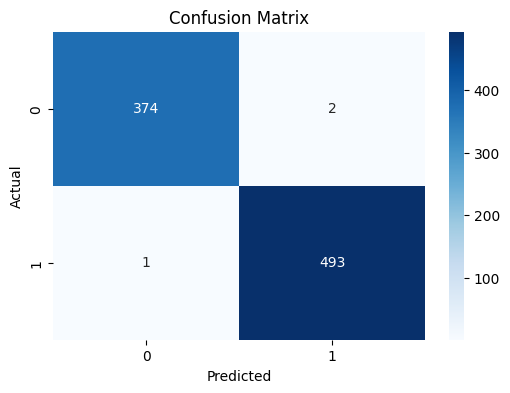

In [29]:
cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


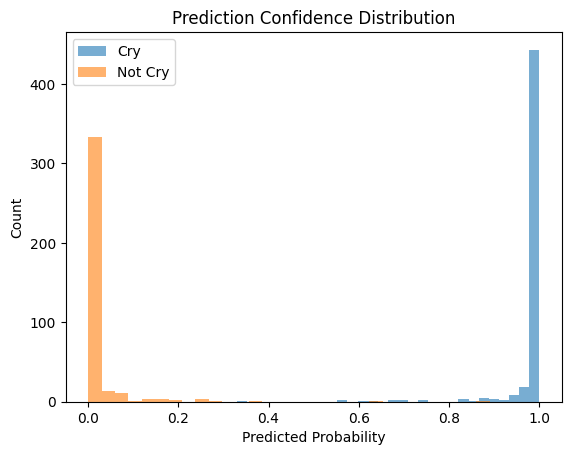

In [31]:
plt.figure()
plt.hist(y_prob[Y_test == 1], bins=30, alpha=0.6, label="Cry")
plt.hist(y_prob[Y_test == 0], bins=30, alpha=0.6, label="Not Cry")
plt.legend()
plt.title("Prediction Confidence Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()


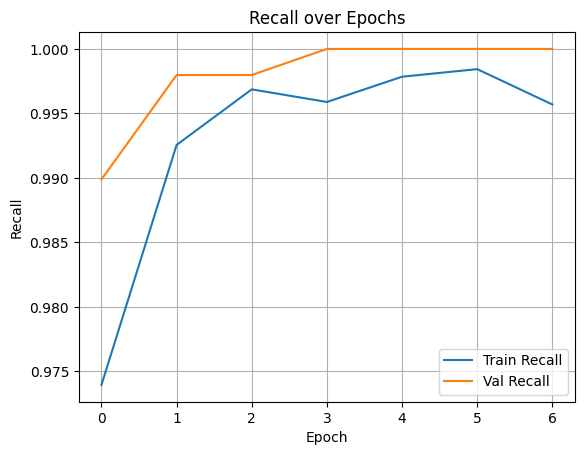

In [ ]:
plt.figure()
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Val Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Recall over Epochs')
plt.legend()
plt.grid(True)
plt.show()


28/28 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step


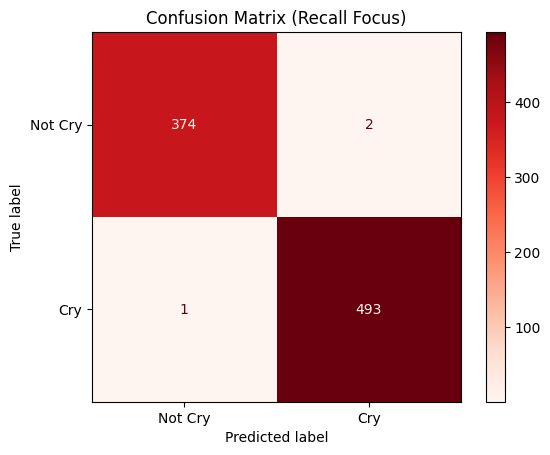

False Negatives (missed cries): 1
Recall = 0.9980


In [32]:
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).reshape(-1)

cm = confusion_matrix(Y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Cry", "Cry"]
)

disp.plot(cmap="Reds")
plt.title("Confusion Matrix (Recall Focus)")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"False Negatives (missed cries): {fn}")
print(f"Recall = {tp / (tp + fn):.4f}")


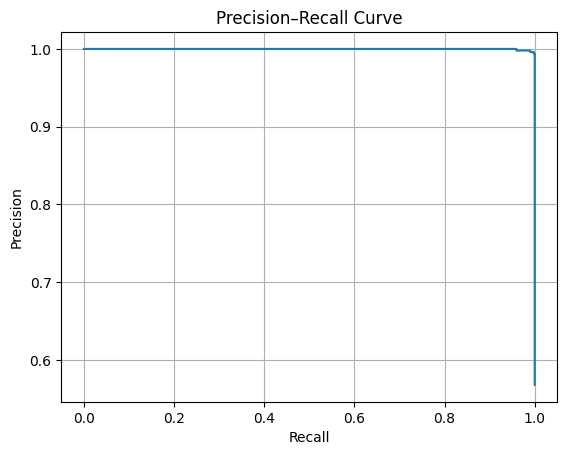

In [33]:
precision, recall, thresholds = precision_recall_curve(Y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)
plt.show()
